# Ray tracing simulation # 

In [1]:
import os, importlib
import mitsuba as mi
print(mi.variants())

# mi.set_variant("llvm_ad_rgb")
mi.set_variant("llvm_ad_mono_polarized")

# Import relevant components from Sionna RT
from sionna.rt import load_scene, PlanarArray, Transmitter, Receiver, Camera,\
                      PathSolver, RadioMapSolver, subcarrier_frequencies

import sionna

# Other imports
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np


# Import relevant components from Sionna RT
from sionna.rt import load_scene, PlanarArray, Transmitter, Receiver, Camera,\
                      PathSolver, RadioMapSolver, subcarrier_frequencies


['scalar_rgb', 'scalar_spectral', 'scalar_spectral_polarized', 'llvm_ad_rgb', 'llvm_ad_mono', 'llvm_ad_mono_polarized', 'llvm_ad_spectral', 'llvm_ad_spectral_polarized', 'cuda_ad_rgb', 'cuda_ad_mono', 'cuda_ad_mono_polarized', 'cuda_ad_spectral', 'cuda_ad_spectral_polarized']


In [42]:
# Import scene as xml file
scene = load_scene("WindowsConfig/WindowsConfig.xml")

scene.tx_array = PlanarArray(num_rows=1,
                             num_cols=1,
                             vertical_spacing=0.5,
                             horizontal_spacing=0.5,
                             pattern='iso',
                             polarization='V')

scene.rx_array = PlanarArray(num_rows=1,
                             num_cols=1,
                             vertical_spacing=0.5,
                             horizontal_spacing=0.5,
                             pattern='iso',
                             polarization='V')

tx = Transmitter("tx", [5, 3, 1.5])
scene.add(tx)

rx = Receiver("rx", [-5, -10, 1.5])
scene.add(rx)

scene.preview()

In [8]:
# mi.set_variant("llvm_ad_mono_polarized")
rm_solver = RadioMapSolver()

rm = rm_solver(scene=scene,
               max_depth=5,
               cell_size=[0.2,0.2],
               samples_per_tx=10**8)

In [9]:
scene.preview(radio_map=rm)

In [48]:
# mi.set_variant("llvm_ad_rgb")
pathSolver = PathSolver()
paths = pathSolver(scene=scene, max_depth=10)

In [49]:
scene.preview(paths=paths)

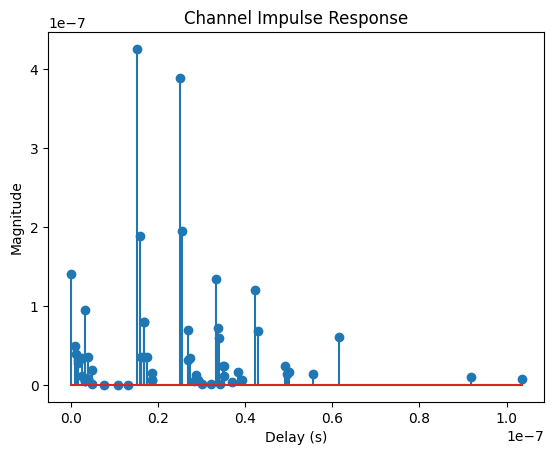

In [50]:
# Channel impulse response of the path
cir = paths.cir(sampling_frequency=10e6,
                num_time_steps=1,
                normalize_delays=True)


coeffs_re, coeffs_im = cir[0]
delays = cir[1]

coeffs_re = coeffs_re[..., :, 0]
coeffs_im = coeffs_im[..., :, 0]
delays = delays[..., :].numpy().reshape(-1)

mag = np.abs(coeffs_re.numpy() + 1j*coeffs_im.numpy()).reshape(-1)


plt.stem(delays, mag)
plt.xlabel("Delay (s)")
plt.ylabel("Magnitude")
plt.title("Channel Impulse Response")
plt.show()